# **Fourier Spectrum Plot**

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [56]:
img = cv2.imread('/kaggle/input/datasets/abhashkharel7/imageippr/bellingham.jpeg',cv2.IMREAD_GRAYSCALE)
img

array([[224, 224, 224, ..., 219, 219, 219],
       [224, 224, 224, ..., 219, 219, 219],
       [224, 224, 224, ..., 219, 219, 219],
       ...,
       [143, 144, 148, ...,  98, 110, 101],
       [148, 146, 156, ...,  99, 114, 111],
       [150, 147, 161, ...,  94, 105, 118]], dtype=uint8)

In [57]:
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
mag_spc = 20 * np.log(np.abs(fshift)+1)

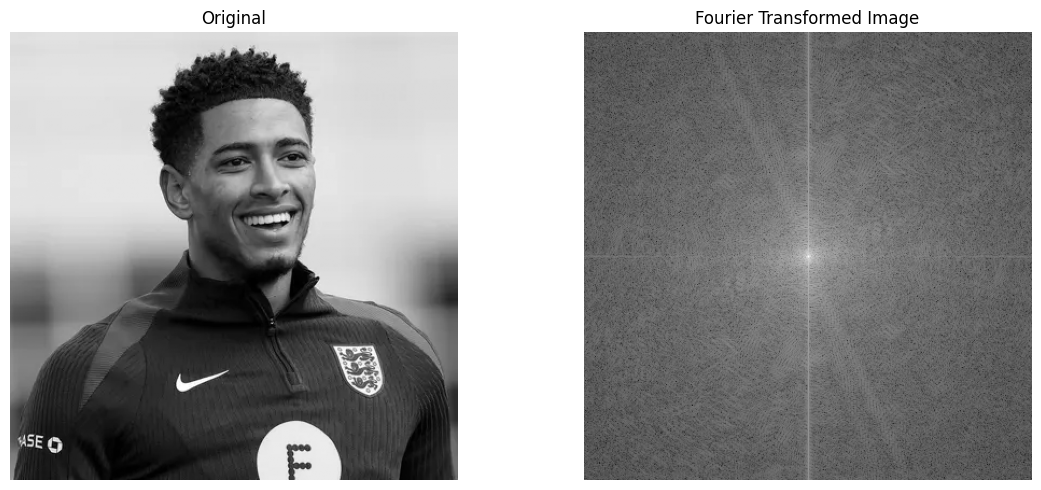

In [58]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(mag_spc, cmap='gray')
plt.title('Fourier Transformed Image')
plt.axis('off')
plt.tight_layout()
plt.show()

# **Ideal Lowpass Filter**

In [59]:
def ideal_lowpass(shape, cutoff):
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2

    H = np.zeros((rows, cols), dtype=np.float32)

    for u in range(rows):
        for v in range(cols):
            D = np.sqrt((u - crow) ** 2 + (v - ccol) ** 2)
            if D <= cutoff:
                H[u, v] = 1

    return H

In [60]:
dft = cv2.dft(np.float32(img), flags = cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

cutoff = 50 

H = ideal_lowpass(img.shape,cutoff)

H3ch = H[:,:,np.newaxis]

filtered = dft_shift * H3ch

f_ishift = np.fft.ifftshift(filtered)
imgb = cv2.idft(f_ishift)
imgb = cv2.magnitude(imgb[:,:,0],imgb[:,:,1])
imgb = cv2.normalize(imgb, None , 0 , 255 , cv2.NORM_MINMAX)
imgb = np.uint8(imgb)

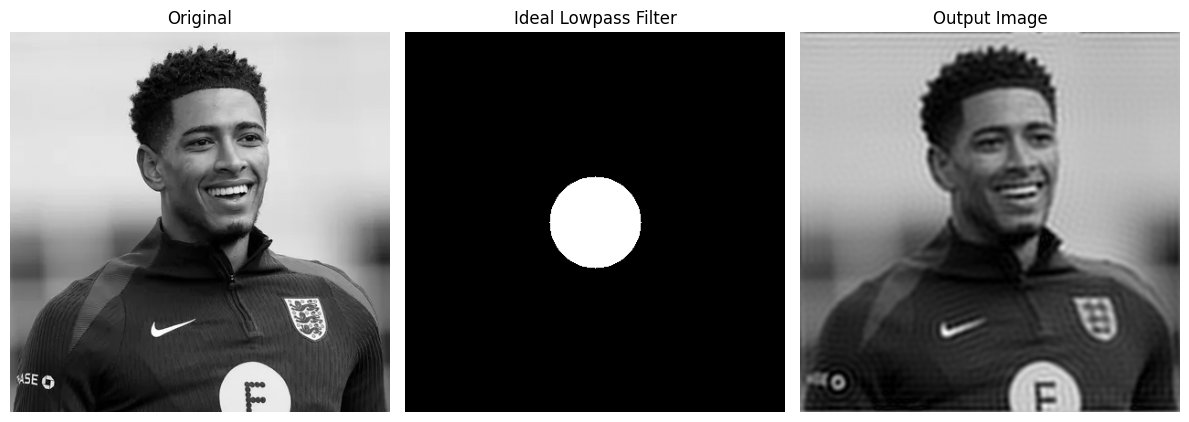

In [61]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(H, cmap='gray')
plt.title('Ideal Lowpass Filter')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(imgb, cmap='gray')
plt.title('Output Image')
plt.axis('off')
plt.tight_layout()
plt.show()

# **Gaussian Lowpass Filter**

In [62]:
def gaussian_lowpass(shape, cutoff):
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2

    H = np.zeros((rows, cols), dtype=np.float32)

    for u in range(rows):
        for v in range(cols):
            D = np.sqrt((u - crow) ** 2 + (v - ccol) ** 2)
            H[u, v] = np.exp(-(D**2)/(2*(cutoff**2)))

    return H

In [63]:
dft = cv2.dft(np.float32(img), flags = cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

cutoff = 50 

H = gaussian_lowpass(img.shape,cutoff)

H3ch = H[:,:,np.newaxis]

filtered = dft_shift * H3ch

f_ishift = np.fft.ifftshift(filtered)
imgb = cv2.idft(f_ishift)
imgb = cv2.magnitude(imgb[:,:,0],imgb[:,:,1])
imgb = cv2.normalize(imgb, None , 0 , 255 , cv2.NORM_MINMAX)
imgb = np.uint8(imgb)

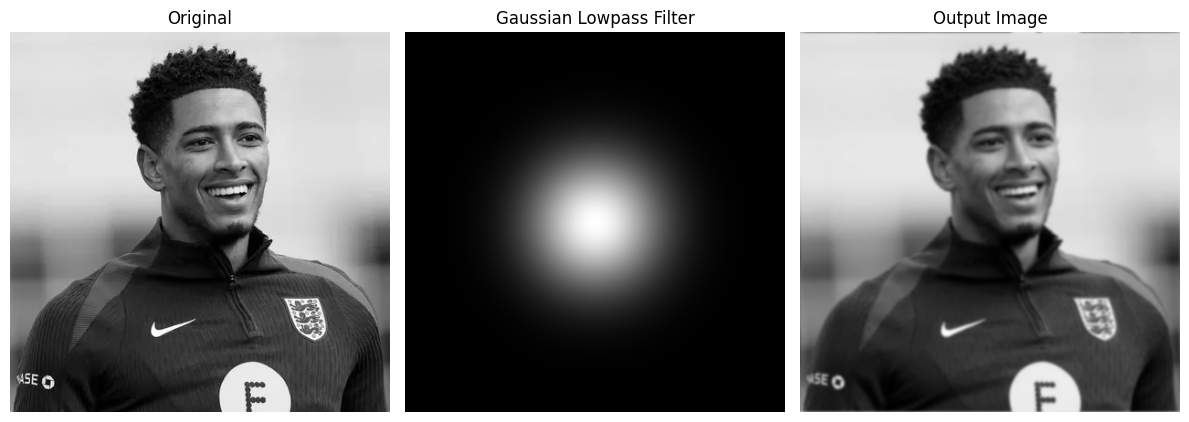

In [64]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(H, cmap='gray')
plt.title('Gaussian Lowpass Filter')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(imgb, cmap='gray')
plt.title('Output Image')
plt.axis('off')
plt.tight_layout()
plt.show()

# **Butterworth Lowpass Filter**

In [65]:
def butterworth_lowpass(shape, cutoff , order):
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2

    H = np.zeros((rows, cols), dtype=np.float32)

    for u in range(rows):
        for v in range(cols):
            D = np.sqrt((u - crow) ** 2 + (v - ccol) ** 2)
            H[u, v] = 1/(1+(D/cutoff)**(2*order))
    return H

In [66]:
dft = cv2.dft(np.float32(img), flags = cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

cutoff = 50 
order = 2

H = butterworth_lowpass(img.shape,cutoff,order)

H3ch = H[:,:,np.newaxis]

filtered = dft_shift * H3ch

f_ishift = np.fft.ifftshift(filtered)
imgb = cv2.idft(f_ishift)
imgb = cv2.magnitude(imgb[:,:,0],imgb[:,:,1])
imgb = cv2.normalize(imgb, None , 0 , 255 , cv2.NORM_MINMAX)
imgb = np.uint8(imgb)

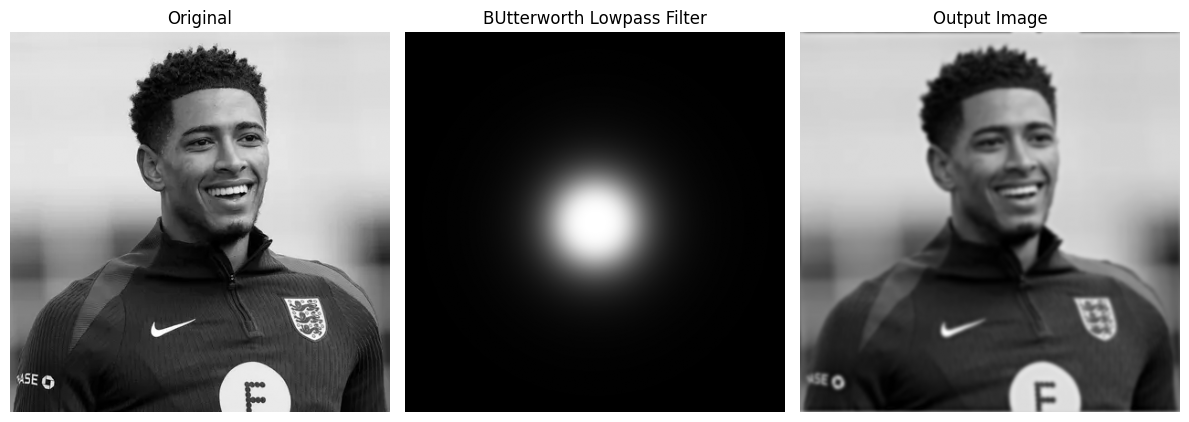

In [67]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(H, cmap='gray')
plt.title('BUtterworth Lowpass Filter')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(imgb, cmap='gray')
plt.title('Output Image')
plt.axis('off')
plt.tight_layout()
plt.show()

# **Ideal Highpass Filter**

In [68]:
def ideal_highpass(shape, cutoff):
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2

    H = np.zeros((rows, cols), dtype=np.float32)

    for u in range(rows):
        for v in range(cols):
            D = np.sqrt((u - crow) ** 2 + (v - ccol) ** 2)
            if D > cutoff:
                H[u, v] = 1

    return H

In [69]:
dft = cv2.dft(np.float32(img), flags = cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

cutoff = 100 

H = ideal_highpass(img.shape,cutoff)

H3ch = H[:,:,np.newaxis]

filtered = dft_shift * H3ch

f_ishift = np.fft.ifftshift(filtered)
imgb = cv2.idft(f_ishift)
imgb = cv2.magnitude(imgb[:,:,0],imgb[:,:,1])
imgb = cv2.normalize(imgb, None , 0 , 255 , cv2.NORM_MINMAX)
imgb = np.uint8(imgb)

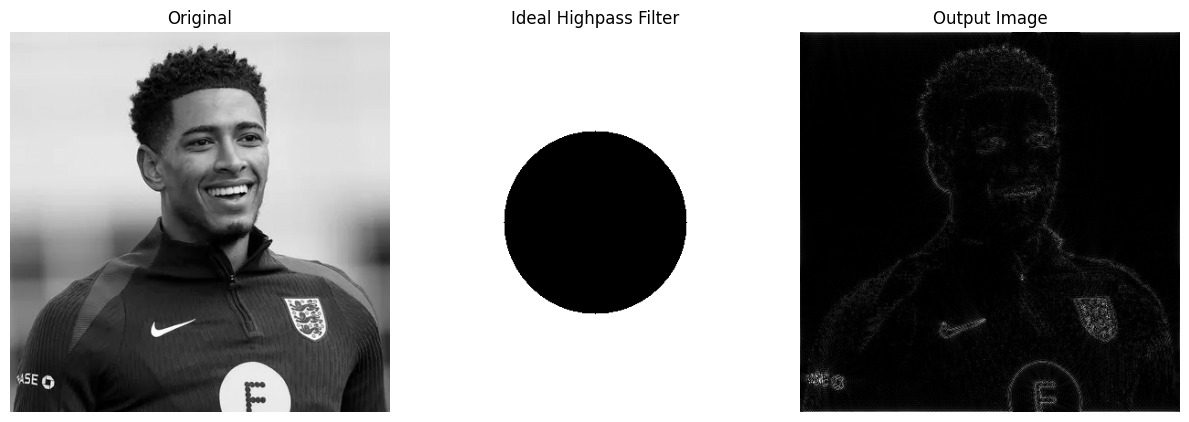

In [70]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(H, cmap='gray')
plt.title('Ideal Highpass Filter')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(imgb, cmap='gray')
plt.title('Output Image')
plt.axis('off')
plt.tight_layout()
plt.show()

# **Gaussian Highpass Filter**

In [71]:
def gaussian_highpass(shape, cutoff):
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2

    H = np.zeros((rows, cols), dtype=np.float32)

    for u in range(rows):
        for v in range(cols):
            D = np.sqrt((u - crow) ** 2 + (v - ccol) ** 2)
            H[u, v] = 1-np.exp(-(D**2)/(2*(cutoff**2)))

    return H

In [72]:
dft = cv2.dft(np.float32(img), flags = cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

cutoff = 100 

H = gaussian_highpass(img.shape,cutoff)

H3ch = H[:,:,np.newaxis]

filtered = dft_shift * H3ch

f_ishift = np.fft.ifftshift(filtered)
imgb = cv2.idft(f_ishift)
imgb = cv2.magnitude(imgb[:,:,0],imgb[:,:,1])
imgb = cv2.normalize(imgb, None , 0 , 255 , cv2.NORM_MINMAX)
imgb = np.uint8(imgb)

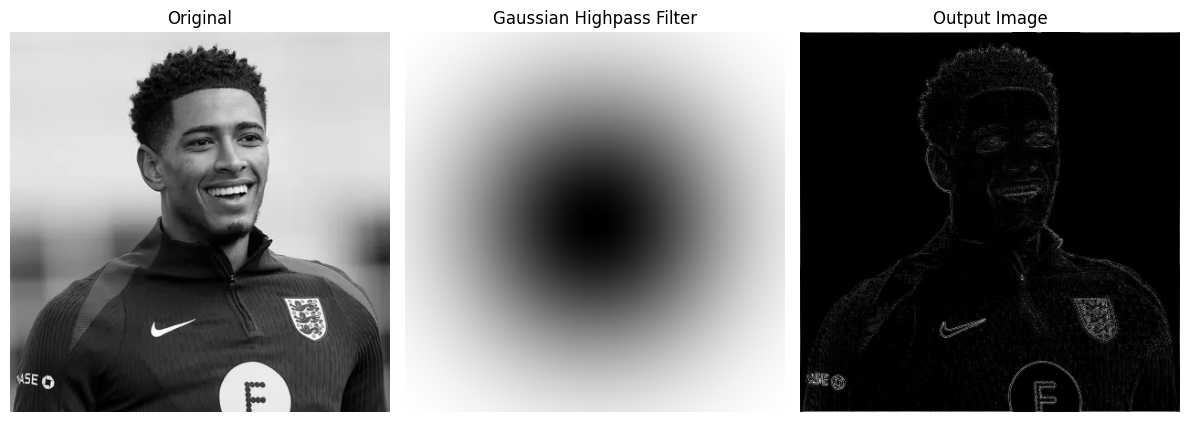

In [73]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(H, cmap='gray')
plt.title('Gaussian Highpass Filter')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(imgb, cmap='gray')
plt.title('Output Image')
plt.axis('off')
plt.tight_layout()
plt.show()

# **Butterworth Highpass Filter**

In [80]:
def butterworth_highpass(shape, cutoff , order):
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2

    H = np.zeros((rows, cols), dtype=np.float32)

    for u in range(rows):
        for v in range(cols):
            D = np.sqrt((u - crow) ** 2 + (v - ccol) ** 2)
            if D== 0:
                H[u,v]=0
            else:
                H[u, v] = (1/(1+(cutoff/D)**(2*order)))
    return H

In [81]:
dft = cv2.dft(np.float32(img), flags = cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

cutoff = 200
order = 2

H = butterworth_highpass(img.shape,cutoff,order)

H3ch = H[:,:,np.newaxis]

filtered = dft_shift * H3ch

f_ishift = np.fft.ifftshift(filtered)
imgb = cv2.idft(f_ishift)
imgb = cv2.magnitude(imgb[:,:,0],imgb[:,:,1])
imgb = cv2.normalize(imgb, None , 0 , 255 , cv2.NORM_MINMAX)
imgb = np.uint8(imgb)

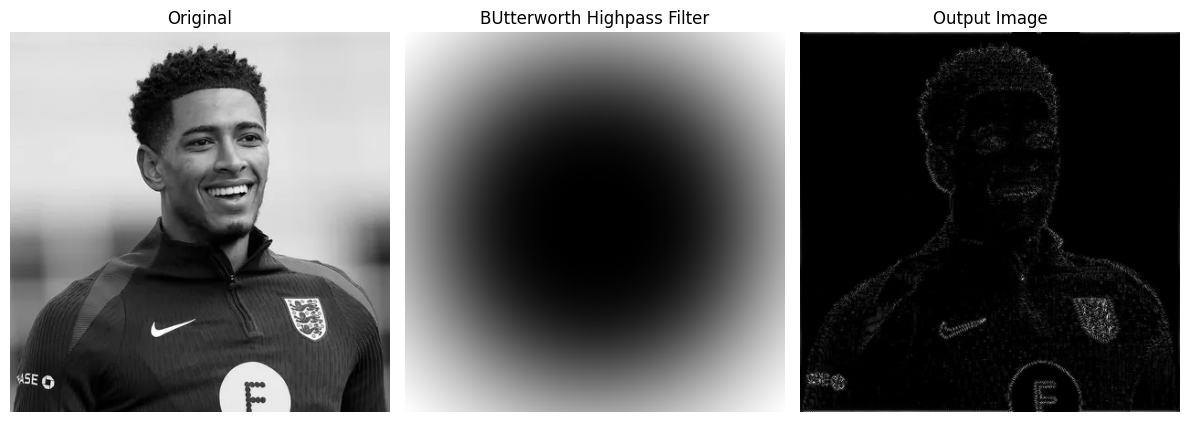

In [82]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(H, cmap='gray')
plt.title('BUtterworth Highpass Filter')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(imgb, cmap='gray')
plt.title('Output Image')
plt.axis('off')
plt.tight_layout()
plt.show()